In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy.ndimage import uniform_filter

In [2]:
def add_gaussian_noise(image, mean=0, std=1):
    """Gaussian noise"""
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

In [3]:
def add_rayleigh_noise(image, scale=1):
    """Rayleigh noise"""
    rayleigh_noise = np.random.rayleigh(scale, image.shape)
    noisy_image = image + rayleigh_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

In [4]:
def add_exponential_noise(image, scale=1):
    """Exponential noise"""
    exponential_noise = np.random.exponential(scale, image.shape)
    noisy_image = image + exponential_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

In [5]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    """Salt & Pepper noise"""
    noisy_image = image.copy()
    # Salt noise (white pixels)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255
    # Pepper noise (black pixels)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 0
    return noisy_image

In [6]:
 def add_uniform_noise(image, low=0, high=10):
    """Uniform noise"""
    uniform_noise = np.random.uniform(low, high, image.shape)
    noisy_image = image + uniform_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

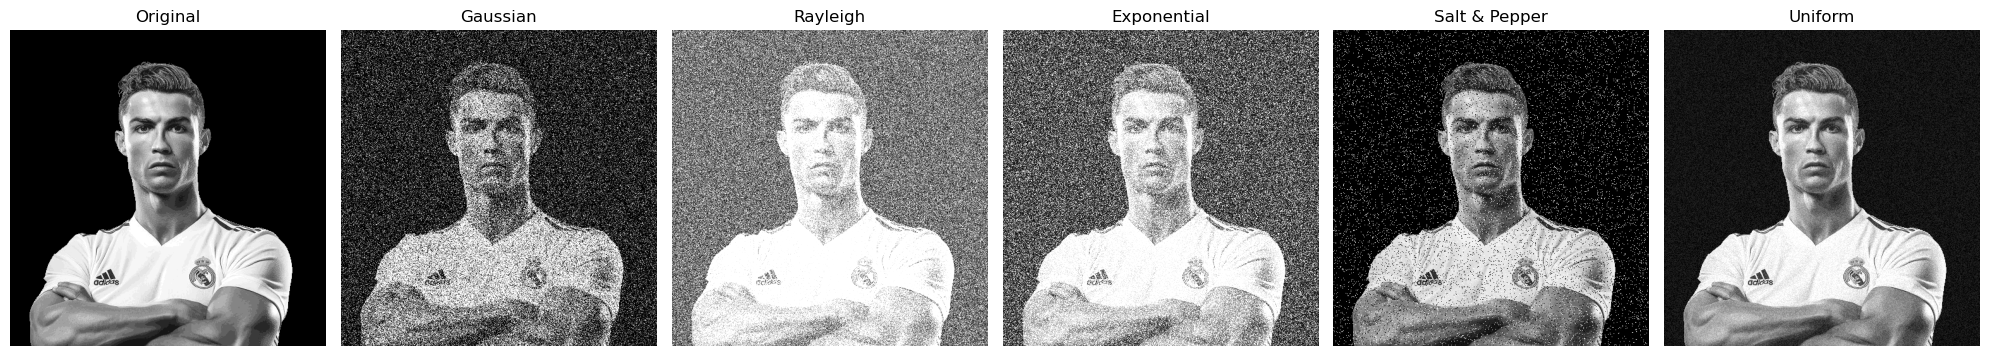

True

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/Users/230166/Desktop/picture.png', cv2.IMREAD_GRAYSCALE)

noisy_gaussian    = add_gaussian_noise(image, mean=0, std=100)
noisy_rayleigh    = add_rayleigh_noise(image, scale=100)
noisy_exponential = add_exponential_noise(image, scale=100)
noisy_salt_pepper = add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05)
noisy_uniform     = add_uniform_noise(image, low=0, high=40)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
titles = ['Original', 'Gaussian', 'Rayleigh', 'Exponential', 'Salt & Pepper', 'Uniform']
images = [image, noisy_gaussian, noisy_rayleigh, noisy_exponential, noisy_salt_pepper, noisy_uniform]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('noisy_gaussian.jpg', noisy_gaussian)

In [16]:
import cv2
import numpy as np
import copy
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# NOISE FUNCTIONS
# ─────────────────────────────────────────────

def add_gaussian_noise(image, mean=0, std=1):
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy_image = image.copy()
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 0
    return noisy_image

# ─────────────────────────────────────────────
# FILTERS
# ─────────────────────────────────────────────

def apply_box(image_input, box, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_box = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i, j] = np.sum(results_box)
    return np.clip(image_box, 0, 255).astype(np.uint8)


def apply_geometric_mean(image_input, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input.astype(np.float64),
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    n = filt_size * filt_size
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            # replace zeros to avoid log(0)
            patch = np.where(patch == 0, 1e-10, patch)
            image_out[i, j] = np.exp(np.sum(np.log(patch)) / n)
    return np.clip(image_out, 0, 255).astype(np.uint8)


def apply_harmonic_mean(image_input, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input.astype(np.float64),
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    n = filt_size * filt_size
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            # replace zeros to avoid division by zero
            patch = np.where(patch == 0, 1e-10, patch)
            image_out[i, j] = n / np.sum(1.0 / patch)
    return np.clip(image_out, 0, 255).astype(np.uint8)


def apply_contraharmonic_mean(image_input, filt_size, Q):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input.astype(np.float64),
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            patch = np.where(patch == 0, 1e-10, patch)
            image_out[i, j] = np.sum(patch ** (Q + 1)) / np.sum(patch ** Q)
    return np.clip(image_out, 0, 255).astype(np.uint8)


def apply_median(image_input, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            image_out[i, j] = np.median(patch)
    return np.clip(image_out, 0, 255).astype(np.uint8)


def apply_max(image_input, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            image_out[i, j] = np.max(patch)
    return np.clip(image_out, 0, 255).astype(np.uint8)


def apply_min(image_input, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            image_out[i, j] = np.min(patch)
    return np.clip(image_out, 0, 255).astype(np.uint8)


def apply_midpoint(image_input, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            image_out[i, j] = (np.max(patch) + np.min(patch)) / 2.0
    return np.clip(image_out, 0, 255).astype(np.uint8)


def apply_alpha_trimmed_mean(image_input, filt_size, d):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_out = copy.deepcopy(image_input).astype(np.float64)
    row, column = image_input.shape
    trim = d // 2
    for i in range(row):
        for j in range(column):
            patch = image_padded[i:i + filt_size, j:j + filt_size].flatten()
            patch_sorted = np.sort(patch)
            # remove d//2 from each end then take the mean
            trimmed = patch_sorted[trim: len(patch_sorted) - trim]
            image_out[i, j] = np.mean(trimmed)
    return np.clip(image_out, 0, 255).astype(np.uint8)


# ─────────────────────────────────────────────
# HELPER: show images and histograms
# ─────────────────────────────────────────────

def show(images, titles):
    n = len(images)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    for i, (img, title) in enumerate(zip(images, titles)):
        axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[0, i].set_title(title)
        axes[0, i].axis('off')
        axes[1, i].hist(img.ravel(), bins=256, range=(0, 255), color='black')
        axes[1, i].set_title('Histogram')
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# LOAD IMAGE
# ─────────────────────────────────────────────

image = cv2.imread('example_image.jpg', cv2.IMREAD_GRAYSCALE)
box3 = np.ones((3, 3), dtype=np.float64) / 9.0
box5 = np.ones((5, 5), dtype=np.float64) / 25.0
box7 = np.ones((7, 7), dtype=np.float64) / 49.0


# ─────────────────────────────────────────────
# TASK 2
# ─────────────────────────────────────────────

# 2.1 Gaussian noise + median filter
noisy = add_gaussian_noise(image, mean=0, std=25)
result = apply_median(noisy, 3)
show([image, noisy, result], ['Original', 'Gaussian Noise', 'Median 3x3'])


# 2.2 Gaussian(mean=0, var=0.0009) + mean and geometric mean filters
# variance=0.0009 on [0,1] scale, so std = sqrt(0.0009)*255
std = np.sqrt(0.0009) * 255
noisy = add_gaussian_noise(image, mean=0, std=std)
mean3   = apply_box(noisy, box3, 3)
mean5   = apply_box(noisy, box5, 5)
geo3    = apply_geometric_mean(noisy, 3)
geo5    = apply_geometric_mean(noisy, 5)
show([image, noisy, mean3, mean5, geo3, geo5],
     ['Original', 'Noisy', 'Mean 3x3', 'Mean 5x5', 'Geo 3x3', 'Geo 5x5'])


# 2.3 Gaussian(mean=0, var=0.09) + same filters + larger windows
std = np.sqrt(0.09) * 255
noisy = add_gaussian_noise(image, mean=0, std=std)
mean3   = apply_box(noisy, box3, 3)
mean5   = apply_box(noisy, box5, 5)
mean7   = apply_box(noisy, box7, 7)
geo3    = apply_geometric_mean(noisy, 3)
geo5    = apply_geometric_mean(noisy, 5)
geo7    = apply_geometric_mean(noisy, 7)
show([image, noisy, mean3, mean5, mean7],
     ['Original', 'Noisy', 'Mean 3x3', 'Mean 5x5', 'Mean 7x7'])
show([image, noisy, geo3, geo5, geo7],
     ['Original', 'Noisy', 'Geo 3x3', 'Geo 5x5', 'Geo 7x7'])


# 2.4 S&P(0.1, 0.1) + median 3x3
noisy = add_salt_pepper_noise(image, salt_prob=0.1, pepper_prob=0.1)
result = apply_median(noisy, 3)
show([image, noisy, result], ['Original', 'S&P 0.1+0.1', 'Median 3x3'])


# 2.5 S&P(0.2, 0.2) + median 3x3, 5x5, 7x7, and 3x3 x4 iterations
noisy = add_salt_pepper_noise(image, salt_prob=0.2, pepper_prob=0.2)
med3  = apply_median(noisy, 3)
med5  = apply_median(noisy, 5)
med7  = apply_median(noisy, 7)
# apply 3x3 median 4 times
med3_iter = noisy.copy()
for _ in range(4):
    med3_iter = apply_median(med3_iter, 3)
show([image, noisy, med3, med5, med7, med3_iter],
     ['Original', 'S&P 0.2+0.2', 'Median 3x3', 'Median 5x5', 'Median 7x7', '3x3 x4 iter'])


# 2.6 Gaussian(0, 0.0009) + salt-only S&P(0.1, 0) + harmonic mean
std = np.sqrt(0.0009) * 255
noisy = add_gaussian_noise(image, mean=0, std=std)
noisy = add_salt_pepper_noise(noisy, salt_prob=0.1, pepper_prob=0)
harm5 = apply_harmonic_mean(noisy, 5)
harm7 = apply_harmonic_mean(noisy, 7)
show([image, noisy, harm5, harm7],
     ['Original', 'Gauss + Salt', 'Harmonic 5x5', 'Harmonic 7x7'])


# 2.7 Salt-only S&P(0.2, 0) + harmonic mean, try different window sizes
noisy = add_salt_pepper_noise(image, salt_prob=0.2, pepper_prob=0)
harm3 = apply_harmonic_mean(noisy, 3)
harm5 = apply_harmonic_mean(noisy, 5)
harm7 = apply_harmonic_mean(noisy, 7)
harm9 = apply_harmonic_mean(noisy, 9)
show([image, noisy, harm3, harm5, harm7, harm9],
     ['Original', 'Salt 0.2', 'Harmonic 3x3', 'Harmonic 5x5', 'Harmonic 7x7', 'Harmonic 9x9'])


# 2.8 Gaussian(0, 0.009) + S&P(0.1, 0.1) + alpha trimmed mean 7x7, vary d
std = np.sqrt(0.009) * 255
noisy = add_gaussian_noise(image, mean=0, std=std)
noisy = add_salt_pepper_noise(noisy, salt_prob=0.1, pepper_prob=0.1)
results = []
labels  = ['Original', 'Noisy']
results.append(image)
results.append(noisy)
for d in [4, 6, 8, 10, 12, 14, 16]:
    results.append(apply_alpha_trimmed_mean(noisy, 7, d))
    labels.append(f'd={d}')
show(results, labels)


# 2.9 Salt-only S&P(0.2, 0) + min filter 3x3
noisy  = add_salt_pepper_noise(image, salt_prob=0.2, pepper_prob=0)
result = apply_min(noisy, 3)
show([image, noisy, result], ['Original', 'Salt 0.2', 'Min 3x3'])


# 2.10 Salt-only S&P(0.5, 0) + min filter, try sizes
noisy  = add_salt_pepper_noise(image, salt_prob=0.5, pepper_prob=0)
min3   = apply_min(noisy, 3)
min5   = apply_min(noisy, 5)
min7   = apply_min(noisy, 7)
show([image, noisy, min3, min5, min7],
     ['Original', 'Salt 0.5', 'Min 3x3', 'Min 5x5', 'Min 7x7'])


# 2.11 Pepper-only S&P(0, 0.2) + max filter 3x3
noisy  = add_salt_pepper_noise(image, salt_prob=0, pepper_prob=0.2)
result = apply_max(noisy, 3)
show([image, noisy, result], ['Original', 'Pepper 0.2', 'Max 3x3'])


# 2.12 Pepper-only S&P(0, 0.5) + max filter, try sizes
noisy  = add_salt_pepper_noise(image, salt_prob=0, pepper_prob=0.5)
max3   = apply_max(noisy, 3)
max5   = apply_max(noisy, 5)
max7   = apply_max(noisy, 7)
show([image, noisy, max3, max5, max7],
     ['Original', 'Pepper 0.5', 'Max 3x3', 'Max 5x5', 'Max 7x7'])


# ─────────────────────────────────────────────
# TASK 3
# ─────────────────────────────────────────────

# 3.1 S&P(0.1, 0.1) + min, max, harmonic, geometric — all 5x5
noisy  = add_salt_pepper_noise(image, salt_prob=0.1, pepper_prob=0.1)
min5   = apply_min(noisy, 5)
max5   = apply_max(noisy, 5)
harm5  = apply_harmonic_mean(noisy, 5)
geo5   = apply_geometric_mean(noisy, 5)
show([image, noisy, min5, max5, harm5, geo5],
     ['Original', 'S&P 0.1+0.1', 'Min 5x5', 'Max 5x5', 'Harmonic 5x5', 'Geo 5x5'])


# 3.2 Salt-only S&P(0.2, 0) + max 5x5 and contraharmonic Q=+2
noisy       = add_salt_pepper_noise(image, salt_prob=0.2, pepper_prob=0)
max5        = apply_max(noisy, 5)
contra_pos  = apply_contraharmonic_mean(noisy, 5, Q=2)
show([image, noisy, max5, contra_pos],
     ['Original', 'Salt 0.2', 'Max 5x5', 'Contraharmonic Q=+2'])


# 3.3 Pepper-only S&P(0, 0.2) + min 5x5, contraharmonic Q=-2, harmonic 5x5
noisy       = add_salt_pepper_noise(image, salt_prob=0, pepper_prob=0.2)
min5        = apply_min(noisy, 5)
contra_neg  = apply_contraharmonic_mean(noisy, 5, Q=-2)
harm5       = apply_harmonic_mean(noisy, 5)
show([image, noisy, min5, contra_neg, harm5],
     ['Original', 'Pepper 0.2', 'Min 5x5', 'Contraharmonic Q=-2', 'Harmonic 5x5'])

[ WARN:0@2068.540] global loadsave.cpp:278 findDecoder imread_('example_image.jpg'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'